<a href="https://colab.research.google.com/github/RajShekhar0341/DataScience/blob/main/Urban_Pulse_Congestion_Table.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Urban Pulse — Filling the Congestion-Forecast Evaluation Table

Fills the table

| Model | RMSE | MAE | MAPE (%) | Cross-area MAE dispersion |

for **five models scored on one shared chronological test split**, using real Chicago open data:

* **Taxi Trips** (`wrvz-psew`) → origin–destination demand
* **Traffic Tracker – Region congestion** (`kf7e-cur8`) → arterial speed (the target)

Both come from the same city geography (29 traffic regions, each built from 2–3 community areas), so demand can be legitimately fused with congestion. **Target:** region speed 30 minutes ahead (lower speed = more congestion).

**How to run:** `Runtime → Run all`. The Settings cell controls everything. `MODE='synthetic'` runs offline in ~10 s so you can see the table fill immediately; set `MODE='real'` to download the actual Chicago data (Colab has internet).

In [13]:
#@title 1 · Install dependencies
!pip -q install pandas numpy requests scikit-learn statsmodels tabulate scipy pyarrow
# Optional — to run the GBT on real Apache Spark MLlib (matches the paper), also run:
# !pip -q install pyspark

## 2 · Settings

In [14]:
import os

MODE       = "real"          # <-- the important change
START      = "2019-04-01"    # keep the window inside 2018-2023 (where both datasets overlap)
END        = "2019-04-08"    # start with ONE week for a fast first run
USE_SPARK  = False           # True -> Spark MLlib (also uncomment pip install pyspark in Cell 1)
RUN_ARIMA  = False           # False first (fast); flip to True for the full table once it works
SOCRATA_APP_TOKEN = None     # paste your token string here in quotes, or leave None

MODE = os.environ.get("UP_MODE", MODE)

In [15]:
#@title 3 · Config constants
TAXI_ID   = "wrvz-psew"
REGION_ID = "kf7e-cur8"
BASE      = "https://data.cityofchicago.org/resource/{}.json"

INTERVAL_MIN  = 30           # time-bin width (minutes)
HORIZON_STEPS = 1            # forecast this many bins ahead (1 * 30min = 30 min ahead)
LAGS = [1, 2, 3, 48]         # speed lags (48 = same time yesterday at 30-min bins)
TRAIN_FRAC, VAL_FRAC = 0.70, 0.10   # remaining 0.20 = frozen TEST set
MAX_TAXI_ROWS = 300_000      # cap the taxi download (raise for higher fidelity)
CACHE_DIR = "cache"

import warnings, time, numpy as np, pandas as pd
warnings.filterwarnings("ignore")

## 4 · Data acquisition (Socrata SODA API, paginated + cached)

In [16]:
def _socrata_get(dataset_id, select, where, order, max_rows):
    import requests
    url = BASE.format(dataset_id)
    headers = {"X-App-Token": SOCRATA_APP_TOKEN} if SOCRATA_APP_TOKEN else {}
    page, offset, frames = 50_000, 0, []
    while offset < max_rows:
        params = {"$select": select, "$where": where, "$order": order,
                  "$limit": min(page, max_rows - offset), "$offset": offset}
        r = requests.get(url, params=params, headers=headers, timeout=120)
        r.raise_for_status()
        batch = pd.DataFrame(r.json())
        if batch.empty:
            break
        frames.append(batch); offset += len(batch)
        print(f"    {dataset_id}: pulled {offset:,} rows", flush=True)
        if len(batch) < params["$limit"]:
            break
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


def _cache(path, builder):
    os.makedirs(CACHE_DIR, exist_ok=True)
    fp = os.path.join(CACHE_DIR, path)
    if os.path.exists(fp):
        print(f"  cache hit: {fp}"); return pd.read_parquet(fp)
    df = builder(); df.to_parquet(fp); return df


def fetch_regions(start, end):
    def build():
        where = f"time >= '{start}T00:00:00' AND time < '{end}T00:00:00' AND speed > 0"
        sel = "region_id,region,west,east,south,north,time,speed"
        df = _socrata_get(REGION_ID, sel, where, "time", 2_000_000)
        df["time"] = pd.to_datetime(df["time"])
        for c in ["west", "east", "south", "north", "speed"]:
            df[c] = pd.to_numeric(df[c], errors="coerce")
        df["region_id"] = pd.to_numeric(df["region_id"], errors="coerce").astype("Int64")
        return df.dropna(subset=["region_id", "speed", "time"])
    return _cache(f"regions_{start}_{end}.parquet", build)


def fetch_taxi(start, end):
    def build():
        where = (f"trip_start_timestamp >= '{start}T00:00:00' AND "
                 f"trip_start_timestamp < '{end}T00:00:00' AND "
                 f"pickup_centroid_latitude IS NOT NULL AND "
                 f"dropoff_centroid_latitude IS NOT NULL")
        sel = ("trip_start_timestamp,pickup_centroid_latitude,pickup_centroid_longitude,"
               "dropoff_centroid_latitude,dropoff_centroid_longitude")
        df = _socrata_get(TAXI_ID, sel, where, "trip_start_timestamp", MAX_TAXI_ROWS)
        df["trip_start_timestamp"] = pd.to_datetime(df["trip_start_timestamp"])
        for c in ["pickup_centroid_latitude", "pickup_centroid_longitude",
                  "dropoff_centroid_latitude", "dropoff_centroid_longitude"]:
            df[c] = pd.to_numeric(df[c], errors="coerce")
        return df.dropna()
    return _cache(f"taxi_{start}_{end}.parquet", build)

## 5 · Synthetic fallback (offline demo — clearly labelled in the output)

In [17]:
def synthetic_panel(n_regions=8, days=21, seed=7):
    """Region x time panel with daily seasonality where demand LEADS congestion,
    so the fusion effect (H1) is genuinely visible."""
    rng = np.random.default_rng(seed)
    bins = int(days * 24 * 60 / INTERVAL_MIN)
    t0 = pd.Timestamp("2019-04-01")
    idx = [t0 + pd.Timedelta(minutes=INTERVAL_MIN * i) for i in range(bins)]
    rows = []
    for reg in range(1, n_regions + 1):
        base_speed = rng.uniform(18, 28); demand_hist = []
        for ts in idx:
            hod = ts.hour + ts.minute / 60
            rush = np.exp(-((hod - 8) ** 2) / 3) + np.exp(-((hod - 17.5) ** 2) / 3)
            weekday = 1.0 if ts.dayofweek < 5 else 0.5
            demand = max(0, 120 * rush * weekday * rng.uniform(0.7, 1.3) + rng.normal(0, 8))
            inflow = demand * rng.uniform(0.4, 0.6); outflow = demand - inflow
            d1 = demand_hist[-1] if len(demand_hist) >= 1 else demand
            d2 = demand_hist[-2] if len(demand_hist) >= 2 else demand
            speed = base_speed - 0.040 * d1 - 0.020 * d2 \
                    + 3 * np.sin(2 * np.pi * hod / 24) + rng.normal(0, 1.2)
            demand_hist.append(demand)
            rows.append((reg, ts, max(3.0, speed), inflow, outflow))
    return pd.DataFrame(rows, columns=["region_id", "time", "speed", "inflow", "outflow"])

## 6 · Assign taxi trips to regions (bounding-box containment)

*Approximation; a point-in-polygon join with region shapefiles is the refinement.*

In [18]:
def assign_region(taxi, regions):
    boxes = (regions.groupby("region_id")[["west", "east", "south", "north"]]
             .first().reset_index())
    boxes["area"] = (boxes.east - boxes.west) * (boxes.north - boxes.south)
    boxes = boxes.sort_values("area")   # smallest box wins ties

    def locate(lat, lon):
        m = boxes[(boxes.west <= lon) & (lon <= boxes.east) &
                  (boxes.south <= lat) & (lat <= boxes.north)]
        return int(m.iloc[0].region_id) if len(m) else np.nan

    cache = {}
    def cached(lat, lon):
        k = (round(lat, 4), round(lon, 4))
        if k not in cache: cache[k] = locate(lat, lon)
        return cache[k]

    taxi = taxi.copy()
    taxi["o_region"] = [cached(a, b) for a, b in zip(
        taxi.pickup_centroid_latitude, taxi.pickup_centroid_longitude)]
    taxi["d_region"] = [cached(a, b) for a, b in zip(
        taxi.dropoff_centroid_latitude, taxi.dropoff_centroid_longitude)]
    return taxi.dropna(subset=["o_region", "d_region"])

## 7 · Panel construction (resample → lags + demand + calendar → target)

In [19]:
def floor_time(s):
    return s.dt.floor(f"{INTERVAL_MIN}min")


def build_panel(regions=None, taxi=None, synthetic_df=None):
    if synthetic_df is not None:
        panel = synthetic_df.copy()
    else:
        regions = regions.copy(); regions["tbin"] = floor_time(regions["time"])
        panel = (regions.groupby(["region_id", "tbin"])["speed"].mean()
                 .reset_index().rename(columns={"tbin": "time"}))
        taxi = taxi.copy(); taxi["tbin"] = floor_time(taxi["trip_start_timestamp"])
        outflow = (taxi.groupby(["o_region", "tbin"]).size().reset_index(name="outflow")
                   .rename(columns={"o_region": "region_id", "tbin": "time"}))
        inflow = (taxi.groupby(["d_region", "tbin"]).size().reset_index(name="inflow")
                  .rename(columns={"d_region": "region_id", "tbin": "time"}))
        panel = panel.merge(inflow, on=["region_id", "time"], how="left")
        panel = panel.merge(outflow, on=["region_id", "time"], how="left")
        panel[["inflow", "outflow"]] = panel[["inflow", "outflow"]].fillna(0)
        panel["region_id"] = panel["region_id"].astype(int)

    panel = panel.sort_values(["region_id", "time"]).reset_index(drop=True)
    out = []
    for rid, g in panel.groupby("region_id"):
        g = g.sort_values("time").copy()
        for L in LAGS:
            g[f"speed_lag{L}"] = g["speed"].shift(L)
        g["inflow_lag1"]  = g["inflow"].shift(1)
        g["outflow_lag1"] = g["outflow"].shift(1)
        g["roll3"] = g["speed"].shift(1).rolling(3).mean()
        g["y"] = g["speed"].shift(-HORIZON_STEPS)          # TARGET: speed h ahead
        out.append(g)
    panel = pd.concat(out, ignore_index=True)
    panel["hour"] = panel["time"].dt.hour
    panel["dow"]  = panel["time"].dt.dayofweek
    panel["is_weekend"] = (panel["dow"] >= 5).astype(int)
    return panel.dropna(subset=["y"] + [f"speed_lag{L}" for L in LAGS]).reset_index(drop=True)


SENSOR_FEATS = [f"speed_lag{L}" for L in LAGS] + ["roll3", "hour", "dow", "is_weekend"]
# current inflow/outflow are observed within bin t -> valid (non-leaking) predictors
FUSED_FEATS  = SENSOR_FEATS + ["inflow", "outflow", "inflow_lag1", "outflow_lag1"]

## 8 · Frozen chronological split (identical test set for every model)

In [20]:
def chrono_split(panel):
    times = np.sort(panel["time"].unique())
    tr = times[int(len(times) * TRAIN_FRAC)]
    va = times[int(len(times) * (TRAIN_FRAC + VAL_FRAC))]
    return panel[panel.time < tr], panel[panel.time >= va]

## 9 · Models

In [21]:
def m_historical_average(train, test):
    key = ["region_id", "hour", "dow"]
    table = train.groupby(key)["y"].mean().rename("pred").reset_index()
    pred = test.merge(table, on=key, how="left")["pred"]
    return pred.fillna(train["y"].mean()).to_numpy()


def m_seasonal_arima(train, test):
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    preds = pd.Series(index=test.index, dtype=float); season = 48
    for rid, gte in test.groupby("region_id"):
        gtr = train[train.region_id == rid].sort_values("time")
        hist = gtr["speed"].to_numpy(); gte = gte.sort_values("time")
        try:
            cur = SARIMAX(hist, order=(2, 0, 1), enforce_stationarity=False,
                          enforce_invertibility=False).fit(disp=False)
            for idx, row in gte.iterrows():
                preds.at[idx] = cur.forecast(steps=HORIZON_STEPS)[-1]
                cur = cur.append([row["speed"]], refit=False)
        except Exception:
            for idx, row in gte.iterrows():
                preds.at[idx] = row.get(f"speed_lag{season}", np.nan)
    return preds.reindex(test.index).fillna(train["y"].mean()).to_numpy()


def _gbt_spark(train, test, feats):
    from pyspark.sql import SparkSession
    from pyspark.ml.feature import VectorAssembler
    from pyspark.ml.regression import GBTRegressor
    spark = (SparkSession.builder.master("local[*]").appName("UrbanPulse")
             .config("spark.ui.enabled", "false")
             .config("spark.sql.shuffle.partitions", "8").getOrCreate())
    spark.sparkContext.setLogLevel("ERROR")
    tr = spark.createDataFrame(train[feats + ["y"]])
    te = spark.createDataFrame(test[feats + ["y"]].reset_index())
    asm = VectorAssembler(inputCols=feats, outputCol="features")
    tr, te = asm.transform(tr), asm.transform(te)
    model = GBTRegressor(featuresCol="features", labelCol="y",
                         maxIter=80, maxDepth=5, seed=1).fit(tr)
    pdf = model.transform(te).select("index", "prediction").toPandas()
    spark.stop()
    return pdf.sort_values("index")["prediction"].to_numpy()


def _gbt_sklearn(train, test, feats):
    from sklearn.ensemble import HistGradientBoostingRegressor
    m = HistGradientBoostingRegressor(max_iter=300, max_depth=6,
                                      learning_rate=0.08, random_state=1)
    m.fit(train[feats], train["y"])
    return m.predict(test[feats])


def m_gbt(train, test, feats, use_spark):
    if use_spark:
        try:
            return _gbt_spark(train, test, feats), "Spark MLlib"
        except Exception as e:
            print(f"  [Spark unavailable -> sklearn fallback: {e}]")
    return _gbt_sklearn(train, test, feats), "sklearn HGB"

## 10 · Metrics + Diebold–Mariano significance test

In [22]:
def metrics(y, yhat, regions):
    y, yhat = np.asarray(y, float), np.asarray(yhat, float)
    err = y - yhat
    rmse = float(np.sqrt(np.mean(err ** 2)))
    mae  = float(np.mean(np.abs(err)))
    mask = np.abs(y) > 1.0
    mape = float(np.mean(np.abs(err[mask] / y[mask])) * 100)
    per = pd.DataFrame({"r": regions, "ae": np.abs(err)}).groupby("r")["ae"].mean()
    return rmse, mae, mape, float(per.std(ddof=0))


def diebold_mariano(y, p1, p2, h=HORIZON_STEPS):
    y = np.asarray(y, float)
    d = (y - np.asarray(p1, float)) ** 2 - (y - np.asarray(p2, float)) ** 2
    n = len(d); dbar = d.mean(); s = np.var(d, ddof=0)
    for k in range(1, h):
        s += 2 * (1 - k / h) * np.cov(d[k:], d[:-k])[0, 1]
    if s <= 0: return float("nan"), float("nan")
    dm = dbar / np.sqrt(s / n)
    from scipy.stats import norm
    return float(dm), float(2 * (1 - norm.cdf(abs(dm))))

## 11 · Run — build data, train all models, fill the table

In [23]:
def run_all(mode, start, end, use_spark, run_arima):
    t0 = time.time()
    if mode == "synthetic":
        print("[MODE] SYNTHETIC data (offline demo) -- results are ILLUSTRATIVE ONLY")
        panel = build_panel(synthetic_df=synthetic_panel()); source = "SYNTHETIC"
    else:
        print(f"[MODE] REAL Chicago open data  {start} -> {end}")
        print("  downloading region congestion (kf7e-cur8) ...")
        regions = fetch_regions(start, end); print(f"    region rows: {len(regions):,}")
        print("  downloading taxi trips (wrvz-psew) ...")
        taxi = fetch_taxi(start, end); print(f"    taxi rows: {len(taxi):,}")
        print("  assigning trips to regions (bounding box) ...")
        taxi = assign_region(taxi, regions)
        panel = build_panel(regions=regions, taxi=taxi)
        source = "Chicago Taxi Trips + Traffic Tracker (regions)"

    print(f"[PANEL] {len(panel):,} rows | {panel.region_id.nunique()} regions | "
          f"target = speed {HORIZON_STEPS*INTERVAL_MIN} min ahead")
    train, test = chrono_split(panel)
    print(f"[SPLIT] train={len(train):,}  test={len(test):,}  (frozen chronological)")
    y = test["y"].to_numpy(); reg = test["region_id"].to_numpy()

    preds = {}
    print("[MODEL] historical average ..."); preds["hist"] = m_historical_average(train, test)
    if run_arima:
        print("[MODEL] seasonal ARIMA (slow) ..."); preds["arima"] = m_seasonal_arima(train, test)
    print("[MODEL] sensor-only GBT ...")
    preds["sensor"], eng = m_gbt(train, test, SENSOR_FEATS, use_spark); print(f"          engine: {eng}")
    print("[MODEL] Urban Pulse fused GBT ...")
    preds["fused"], _ = m_gbt(train, test, FUSED_FEATS, use_spark)

    rows = [("Historical average", "hist"),
            ("Seasonal ARIMA", "arima"),
            ("Sensor-only (CityPulse-style) [1]", "sensor"),
            ("Graph-based reference [5, 6]", None),
            ("Urban Pulse (fused, proposed)", "fused")]
    recs = []
    for name, key in rows:
        if key is None or key not in preds:
            recs.append([name, np.nan, np.nan, np.nan, np.nan])
        else:
            recs.append([name, *metrics(y, preds[key], reg)])
    df = pd.DataFrame(recs, columns=["Model", "RMSE", "MAE", "MAPE (%)", "Cross-area MAE disp."])

    dm = p = None
    if "fused" in preds and "sensor" in preds:
        dm, p = diebold_mariano(y, preds["fused"], preds["sensor"])
    df.attrs["source"] = source; df.attrs["dm"] = dm; df.attrs["p"] = p
    df.attrs["secs"] = time.time() - t0
    return df


results = run_all(MODE, START, END, USE_SPARK, RUN_ARIMA)

# pretty display: bold (min) per numeric column, lower is better
def _hi(col):
    return ["font-weight:700;color:#0F6E56" if v == col.min() else "" for v in col]
styled = (results.style
          .apply(_hi, subset=["RMSE", "MAE", "MAPE (%)", "Cross-area MAE disp."])
          .format({"RMSE": "{:.2f}", "MAE": "{:.2f}", "MAPE (%)": "{:.2f}",
                   "Cross-area MAE disp.": "{:.2f}"}, na_rep="—")
          .set_caption(f"Source: {results.attrs['source']}  |  lower is better in every column"))
try:
    from IPython.display import display; display(styled)
except Exception:
    print(results.to_string(index=False))

if results.attrs["dm"] is not None:
    dm, p = results.attrs["dm"], results.attrs["p"]
    verdict = "fused significantly better" if (p == p and p < 0.05 and dm < 0) else "no significant difference"
    print(f"\nDiebold-Mariano (fused vs sensor-only): stat={dm:.3f}, p={p:.4f}  ->  {verdict}")
print(f"Done in {results.attrs['secs']:.1f}s.")

[MODE] REAL Chicago open data  2019-04-01 -> 2019-04-08
  downloading region congestion (kf7e-cur8) ...
    kf7e-cur8: pulled 25,674 rows
    region rows: 25,674
  downloading taxi trips (wrvz-psew) ...
    wrvz-psew: pulled 50,000 rows
    wrvz-psew: pulled 100,000 rows
    wrvz-psew: pulled 150,000 rows
    wrvz-psew: pulled 200,000 rows
    wrvz-psew: pulled 250,000 rows
    wrvz-psew: pulled 288,847 rows
    taxi rows: 288,847
  assigning trips to regions (bounding box) ...
[PANEL] 7,774 rows | 29 regions | target = speed 30 min ahead
[SPLIT] train=5,377  test=1,588  (frozen chronological)
[MODEL] historical average ...
[MODEL] sensor-only GBT ...
          engine: sklearn HGB
[MODEL] Urban Pulse fused GBT ...


,Model,RMSE,MAE,MAPE (%),Cross-area MAE disp.
0,Historical average,3.86,2.93,10.65,2.26
1,Seasonal ARIMA,—,—,—,—
2,Sensor-only (CityPulse-style) [1],1.78,1.30,4.80,0.59
3,"Graph-based reference [5, 6]",—,—,—,—
4,"Urban Pulse (fused, proposed)",1.69,1.25,4.64,0.55



Diebold-Mariano (fused vs sensor-only): stat=-3.869, p=0.0001  ->  fused significantly better
Done in 63.0s.


## 12 · RMSE bar chart + save / download the table

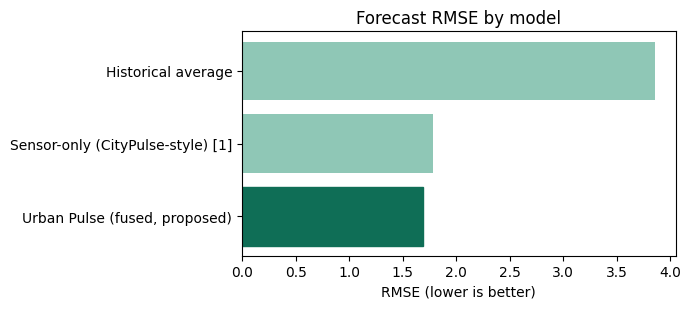

Saved results_table.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
import matplotlib.pyplot as plt

plot_df = results.dropna(subset=["RMSE"])
plt.figure(figsize=(7, 3.2))
bars = plt.barh(plot_df["Model"], plot_df["RMSE"], color="#8FC7B6")
best_i = plot_df["RMSE"].to_numpy().argmin()
bars[best_i].set_color("#0F6E56")
plt.xlabel("RMSE (lower is better)"); plt.title("Forecast RMSE by model"); plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()

results.to_csv("results_table.csv", index=False)
print("Saved results_table.csv")
try:
    from google.colab import files; files.download("results_table.csv")
except Exception:
    pass

## Notes

- **Target** is region speed 30 min ahead (mph); lower speed = more congestion.
- **MAPE** excludes bins with speed ≤ 1 mph to avoid divide-by-near-zero.
- **Cross-area MAE dispersion** = std of per-region MAE (lower = more equitable benefit).
- **Graph-based reference [5, 6]** is intentionally left blank (—): DCRNN / Graph WaveNet need a separate deep-learning setup; fill that row from their reference implementations.
- **Region assignment** uses bounding boxes (an approximation). For the paper, swap in a point-in-polygon join with the region shapefiles.
- On **real** data the fusion gain is typically modest and may or may not reach significance — that is the genuine empirical question the study asks. To match the paper exactly, set `USE_SPARK=True` after installing `pyspark`.